# Water Segmentation using Multispectral Data
## Week 2: Pretrained Encoder Fine-Tuning vs. Week 1 Scratch U-Net


In [1]:
# =====================================
# Import Required Libraries
# =====================================

import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp


c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =====================================
# Dataset Paths
# =====================================

DATA_DIR = "data"

IMAGE_DIR = os.path.join(DATA_DIR, "images")
LABEL_DIR = os.path.join(DATA_DIR, "labels")


In [3]:
# =====================================
# Read Image and Label Names
# =====================================

image_files = sorted(os.listdir(IMAGE_DIR))
label_files = sorted(os.listdir(LABEL_DIR))

print(f"Number of Images : {len(image_files)}")
print(f"Number of Labels : {len(label_files)}")


Number of Images : 306
Number of Labels : 456


c:\Python\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Image Shape : (12, 128, 128)


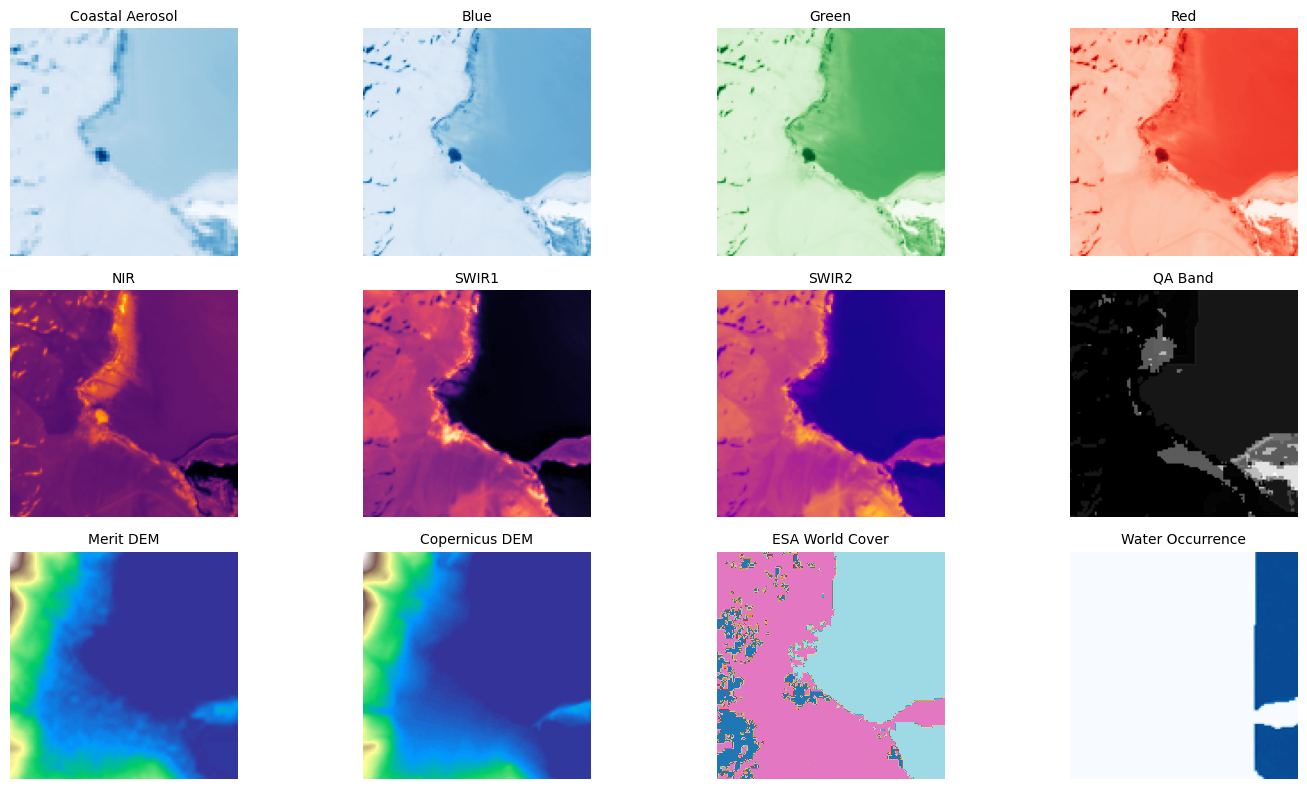

In [4]:
# =====================================
# Display a Random Image and its Bands
# =====================================

image_path = os.path.join(IMAGE_DIR, random.choice(image_files))

with rasterio.open(image_path) as src:
    image = src.read()

print("Image Shape :", image.shape)

band_names = [
    "Coastal Aerosol",
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "QA Band",
    "Merit DEM",
    "Copernicus DEM",
    "ESA World Cover",
    "Water Occurrence"
]
band_cmaps = [
    "Blues",      # Coastal Aerosol
    "Blues",      # Blue
    "Greens",     # Green
    "Reds",       # Red
    "inferno",    # NIR
    "magma",      # SWIR1
    "plasma",     # SWIR2
    "gray",       # QA Band
    "terrain",    # Merit DEM
    "terrain",    # Copernicus DEM
    "tab20",      # ESA World Cover
    "Blues"       # Water Occurrence Probability
]

plt.figure(figsize=(15,8))

for i in range(image.shape[0]):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i], cmap=band_cmaps[i])
    plt.title(band_names[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


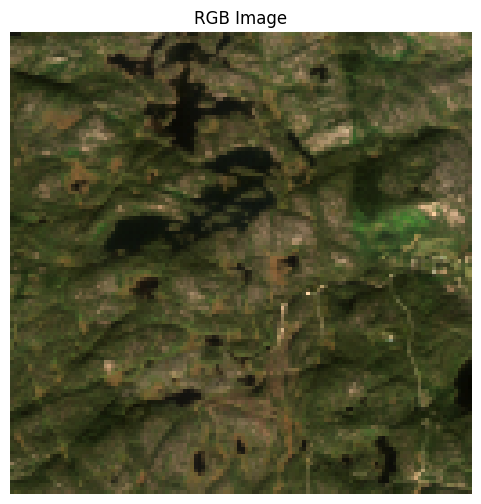

In [5]:
# =====================================
# Display a Random Image as RGB
# =====================================

sample_path = os.path.join(IMAGE_DIR, image_files[0])

with rasterio.open(sample_path) as src:
    image = src.read().astype(np.float32)

rgb = np.stack([
    image[3],   # Red
    image[2],   # Green
    image[1]    # Blue
], axis=-1)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")
plt.show()


In [6]:
# =====================================
# Train Validation Split
# =====================================

all_files = sorted(os.listdir(IMAGE_DIR))

train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

print("Train Images :", len(train_files))
print("Validation Images :", len(val_files))


Train Images : 244
Validation Images : 62


In [7]:
# =====================================
# Compute Global Band Statistics (Training Set Only)
# =====================================

# Per-image min/max normalization (used in the Week 1 scratch model below)
# makes the same physical value map to a different number in every image,
# which hurts training. Here we compute [low_pct, high_pct] percentile
# bounds PER BAND, ONCE, using ONLY the training files (never validation -
# that would leak info). Percentiles (instead of raw min/max) protect
# against isolated outlier pixels (sensor noise, clouds, etc.).
#

LOWER_PERCENTILE = 2
UPPER_PERCENTILE = 98

def compute_global_band_stats(file_list, image_dir, lower_pct=2, upper_pct=98,
                               sample_stride=4):
    """
    Returns dict: band_index -> (low_value, high_value)
    """
    band_values = None

    for fname in file_list:
        path = os.path.join(image_dir, fname)
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # (bands, H, W)

        if band_values is None:
            band_values = [[] for _ in range(img.shape[0])]

        for b in range(img.shape[0]):
            sampled = img[b][::sample_stride, ::sample_stride]
            band_values[b].append(sampled.flatten())

    stats = {}
    for b, vals in enumerate(band_values):
        all_vals = np.concatenate(vals)
        low = np.percentile(all_vals, lower_pct)
        high = np.percentile(all_vals, upper_pct)
        stats[b] = (float(low), float(high))

    return stats

GLOBAL_BAND_STATS = compute_global_band_stats(
    train_files,
    IMAGE_DIR,
    lower_pct=LOWER_PERCENTILE,
    upper_pct=UPPER_PERCENTILE
)

print(f"Global per-band [{LOWER_PERCENTILE}th, {UPPER_PERCENTILE}th] percentile bounds (from training set):")
for b, (low, high) in GLOBAL_BAND_STATS.items():
    label = band_names[b] if b < len(band_names) else f"Band {b}"
    print(f"  Band {b:2d} ({label:18s}) : [{low:10.4f}, {high:10.4f}]")


Global per-band [2th, 98th] percentile bounds (from training set):
  Band  0 (Coastal Aerosol   ) : [   83.0000,   941.0000]
  Band  1 (Blue              ) : [  107.0000,  1146.0000]
  Band  2 (Green             ) : [  242.0000,  1746.0000]
  Band  3 (Red               ) : [  109.0000,  2482.0000]
  Band  4 (NIR               ) : [  139.0000,  4075.9062]
  Band  5 (SWIR1             ) : [   13.0000,  4482.0000]
  Band  6 (SWIR2             ) : [   12.0000,  3773.0000]
  Band  7 (QA Band           ) : [   64.0000,   224.0000]
  Band  8 (Merit DEM         ) : [   15.0000,  1836.0000]
  Band  9 (Copernicus DEM    ) : [   17.0000,  1841.0000]
  Band 10 (ESA World Cover   ) : [   10.0000,    80.0000]
  Band 11 (Water Occurrence  ) : [    0.0000,    98.0000]


In [8]:
# =====================================
# Data Augmentation
# =====================================

train_transform = A.Compose([
    # --- Geometric augmentations ---
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=25,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.GridDistortion(p=0.2),
    A.ElasticTransform(alpha=1, sigma=30, p=0.2),

    # --- Intensity / noise augmentations ---
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),
    A.GaussNoise(p=0.3),
    A.CoarseDropout(p=0.2),
])

# No augmentation for validation/test data - just pass images through
val_transform = A.Compose([])


c:\Python\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
# =====================================
# Custom Dataset Class (Week 2 - pretrained pipeline)
# =====================================

class WaterDataset(Dataset):

    def __init__(self, file_list, image_dir, label_dir, channels, band_stats, transform=None):
        self.file_list = file_list
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.channels = channels
        self.band_stats = band_stats
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        image_name = self.file_list[idx]
        mask_name = image_name.replace(".tif", ".png")

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.label_dir, mask_name)

        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)
            image = image[self.channels]

        # Normalize each band using GLOBAL statistics (computed once from
        # the training set), not per-image min/max.
        for i, ch in enumerate(self.channels):
            low, high = self.band_stats[ch]
            band = np.clip(image[i], low, high)
            image[i] = (band - low) / (high - low + 1e-8)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = mask.astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(
                image=np.transpose(image, (1, 2, 0)),
                mask=mask
            )
            image = np.transpose(transformed["image"], (2, 0, 1))
            mask = transformed["mask"]

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [10]:
# =====================================
# Device & Batch Size
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16

print("Using device :", device)
print("Batch size   :", BATCH_SIZE)


Using device : cpu
Batch size   : 16


In [11]:
# =====================================
# Define Loss Function
# =====================================

criterion = nn.BCEWithLogitsLoss()


In [12]:
# =====================================
# Dice Score
# =====================================

def dice_score(preds, targets):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    dice = (2 * intersection + 1e-8) / (preds.sum() + targets.sum() + 1e-8)
    return dice.item()


In [13]:
# =====================================
# IoU Score
# =====================================

def iou_score(preds, targets):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    iou = (intersection + 1e-8) / (union + 1e-8)
    return iou.item()


In [14]:
# =====================================
# Training Function
# =====================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [15]:
# =====================================
# Validation Function
# =====================================

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_score(outputs, masks)
            total_iou += iou_score(outputs, masks)

    return (
        total_loss / len(loader),
        total_dice / len(loader),
        total_iou / len(loader)
    )


In [16]:
# =====================================
# Full Metrics Evaluation (Dice, IoU, Precision, Recall, F1)
# =====================================

# Used for BOTH the Week 1 scratch model and the Week 2 pretrained model, so
# the final comparison table (further below) is built the exact same way
# for each - this is the "same metrics" comparison the task asks for.

def evaluate_full_metrics(model, loader, device):
    model.eval()

    all_preds = []
    all_masks = []
    dice_total = 0
    iou_total = 0
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks_dev = masks.to(device)

            outputs = model(images)

            dice_total += dice_score(outputs, masks_dev)
            iou_total += iou_score(outputs, masks_dev)
            n_batches += 1

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_masks.extend(masks.numpy().flatten())

    precision = precision_score(all_masks, all_preds, zero_division=0)
    recall = recall_score(all_masks, all_preds, zero_division=0)
    f1 = f1_score(all_masks, all_preds, zero_division=0)

    return {
        "Dice": dice_total / n_batches,
        "IoU": iou_total / n_batches,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


## Optional Exploration: Channel Combination Experiment

The task requires the final model to accept the **full 12-channel** input, so
this section is **not** part of the required pipeline - it's kept as a side
experiment to see whether a smaller band subset could match/beat the full
12-band input (useful context for a "future work" note in the findings).
`SELECTED_CHANNELS` is forced back to all 12 bands right after this section,
regardless of what wins here.


In [17]:
# =====================================
# Helper Functions for Channel Experiments (optional exploration only)
# =====================================

def build_loaders(channels, batch_size=BATCH_SIZE):
    tr_ds = WaterDataset(
        train_files, IMAGE_DIR, LABEL_DIR,
        channels=channels, band_stats=GLOBAL_BAND_STATS,
        transform=train_transform
    )
    va_ds = WaterDataset(
        val_files, IMAGE_DIR, LABEL_DIR,
        channels=channels, band_stats=GLOBAL_BAND_STATS,
        transform=val_transform
    )
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False)
    return tr_loader, va_loader


def build_model(in_channels, encoder_name="resnet34"):
    return smp.Unet(
        encoder_name=encoder_name,
        encoder_weights="imagenet",
        in_channels=in_channels,
        classes=1
    ).to(device)


def run_channel_experiment(name, channels, epochs, encoder_name="resnet34", lr=1e-4):
    print(f"\n=== {name}  ->  channels {channels} ===")

    tr_loader, va_loader = build_loaders(channels)
    model_exp = build_model(in_channels=len(channels), encoder_name=encoder_name)
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "dice": [], "iou": []}

    for epoch in range(epochs):
        train_loss = train_one_epoch(model_exp, tr_loader, optimizer_exp, criterion, device)
        val_loss, dice, iou = validate_one_epoch(model_exp, va_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["dice"].append(dice)
        history["iou"].append(iou)

        print(f"  Epoch [{epoch+1}/{epochs}] | Val Loss: {val_loss:.4f} | Dice: {dice:.4f} | IoU: {iou:.4f}")

    return {
        "channels": channels,
        "final_dice": history["dice"][-1],
        "final_iou": history["iou"][-1],
        "best_dice": max(history["dice"]),
        "best_iou": max(history["iou"]),
        "history": history,
    }


In [18]:
# =====================================
# Define Channel Combinations to Compare (optional exploration only)
# =====================================

# 0 Coastal Aerosol, 1 Blue, 2 Green, 3 Red, 4 NIR, 5 SWIR1, 6 SWIR2,
# 7 QA Band, 8 Merit DEM, 9 Copernicus DEM, 10 ESA World Cover, 11 Water Occurrence
#
# Band 11 (Water Occurrence) is deliberately excluded here - it's a
# pre-computed water-probability layer, so including it risks leaking
# near-answer information rather than testing genuine spectral signal.
CHANNEL_COMBINATIONS = {
    "Baseline: Green, NIR, SWIR1":  [2, 4, 5],
    "Green, NIR, SWIR2":            [2, 4, 6],
    "Blue, Green, NIR":             [1, 2, 4],
    "Green, SWIR1, SWIR2":          [2, 5, 6],
    "All optical bands (0-6)":      [0, 1, 2, 3, 4, 5, 6],
}

EXPERIMENT_EPOCHS = 10

experiment_results = {}
for name, channels in CHANNEL_COMBINATIONS.items():
    experiment_results[name] = run_channel_experiment(
        name, channels, epochs=EXPERIMENT_EPOCHS
    )



=== Baseline: Green, NIR, SWIR1  ->  channels [2, 4, 5] ===
  Epoch [1/10] | Val Loss: 0.7648 | Dice: 0.5050 | IoU: 0.3414
  Epoch [2/10] | Val Loss: 0.5522 | Dice: 0.5966 | IoU: 0.4305
  Epoch [3/10] | Val Loss: 0.4844 | Dice: 0.6718 | IoU: 0.5095
  Epoch [4/10] | Val Loss: 0.4366 | Dice: 0.7184 | IoU: 0.5640
  Epoch [5/10] | Val Loss: 0.3826 | Dice: 0.7506 | IoU: 0.6050
  Epoch [6/10] | Val Loss: 0.3451 | Dice: 0.7823 | IoU: 0.6458
  Epoch [7/10] | Val Loss: 0.3382 | Dice: 0.7653 | IoU: 0.6256
  Epoch [8/10] | Val Loss: 0.3274 | Dice: 0.7772 | IoU: 0.6410
  Epoch [9/10] | Val Loss: 0.3106 | Dice: 0.7766 | IoU: 0.6407
  Epoch [10/10] | Val Loss: 0.2943 | Dice: 0.7905 | IoU: 0.6588

=== Green, NIR, SWIR2  ->  channels [2, 4, 6] ===
  Epoch [1/10] | Val Loss: 1.1849 | Dice: 0.3929 | IoU: 0.2470
  Epoch [2/10] | Val Loss: 0.7049 | Dice: 0.5035 | IoU: 0.3402
  Epoch [3/10] | Val Loss: 0.5494 | Dice: 0.6338 | IoU: 0.4673
  Epoch [4/10] | Val Loss: 0.4814 | Dice: 0.7029 | IoU: 0.5467
  Epo

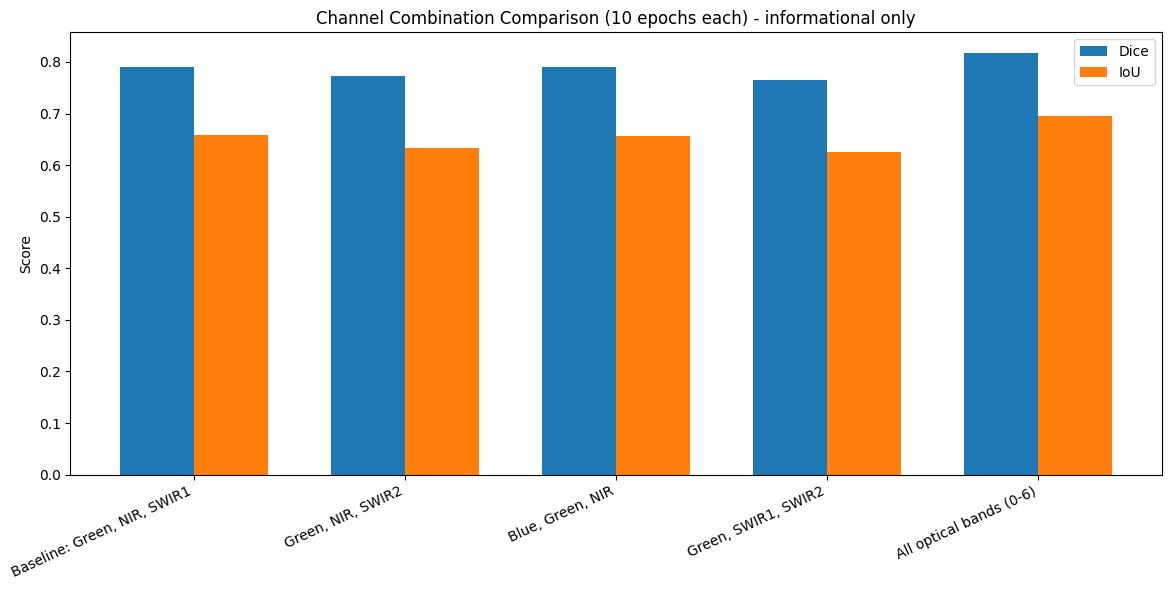

Summary:
  Baseline: Green, NIR, SWIR1      | Dice: 0.7905 | IoU: 0.6588 | channels=[2, 4, 5]
  Green, NIR, SWIR2                | Dice: 0.7728 | IoU: 0.6339 | channels=[2, 4, 6]
  Blue, Green, NIR                 | Dice: 0.7898 | IoU: 0.6561 | channels=[1, 2, 4]
  Green, SWIR1, SWIR2              | Dice: 0.7648 | IoU: 0.6248 | channels=[2, 5, 6]
  All optical bands (0-6)          | Dice: 0.8165 | IoU: 0.6949 | channels=[0, 1, 2, 3, 4, 5, 6]

Best subset by Dice (informational): 'All optical bands (0-6)' -> channels [0, 1, 2, 3, 4, 5, 6]
(Not used below - the task requires the final model to use all 12 channels.)


In [19]:
# =====================================
# Compare Results (optional exploration only)
# =====================================

names = list(experiment_results.keys())
final_dice = [experiment_results[n]["final_dice"] for n in names]
final_iou = [experiment_results[n]["final_iou"] for n in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, final_dice, width, label="Dice")
plt.bar(x + width/2, final_iou, width, label="IoU")
plt.xticks(x, names, rotation=25, ha="right")
plt.ylabel("Score")
plt.title(f"Channel Combination Comparison ({EXPERIMENT_EPOCHS} epochs each) - informational only")
plt.legend()
plt.tight_layout()
plt.show()

print("Summary:")
for name in names:
    r = experiment_results[name]
    print(f"  {name:32s} | Dice: {r['final_dice']:.4f} | IoU: {r['final_iou']:.4f} | channels={r['channels']}")

best_combo = max(experiment_results, key=lambda n: experiment_results[n]["final_dice"])
best_combo_channels = experiment_results[best_combo]["channels"]
print(f"\nBest subset by Dice (informational): '{best_combo}' -> channels {best_combo_channels}")
print("(Not used below - the task requires the final model to use all 12 channels.)")


In [20]:
# =====================================
# Final Channel Selection - forced to all 12 channels per task requirement
# =====================================

ALL_CHANNELS = list(range(12))
SELECTED_CHANNELS = ALL_CHANNELS

print("Selected channels for the required pipeline:", SELECTED_CHANNELS)
print("->", [band_names[c] for c in SELECTED_CHANNELS])


Selected channels for the required pipeline: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
-> ['Coastal Aerosol', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA Band', 'Merit DEM', 'Copernicus DEM', 'ESA World Cover', 'Water Occurrence']


In [21]:
# =====================================
# Create Dataset Objects
# =====================================

train_dataset = WaterDataset(
    train_files,
    IMAGE_DIR,
    LABEL_DIR,
    channels=SELECTED_CHANNELS,
    band_stats=GLOBAL_BAND_STATS,
    transform=train_transform
)
val_dataset = WaterDataset(
    val_files,
    IMAGE_DIR,
    LABEL_DIR,
    channels=SELECTED_CHANNELS,
    band_stats=GLOBAL_BAND_STATS,
    transform=val_transform
)

print("Train Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))


Train Samples : 244
Validation Samples : 62


In [22]:
# =====================================
# Test Dataset
# =====================================

image, mask = train_dataset[0]

print("Image Shape :", image.shape)
print("Mask Shape :", mask.shape)
print("Image Dtype :", image.dtype)
print("Mask Dtype :", mask.dtype)


Image Shape : torch.Size([12, 128, 128])
Mask Shape : torch.Size([1, 128, 128])
Image Dtype : torch.float32
Mask Dtype : torch.float32


c:\Python\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [23]:
# =====================================
# Create DataLoaders
# =====================================

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train Batches : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")


Train Batches : 16
Validation Batches : 4


In [24]:
# =====================================
# Test DataLoader
# =====================================

images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)


Images Shape : torch.Size([16, 12, 128, 128])
Masks Shape  : torch.Size([16, 1, 128, 128])


## Adapting a Pretrained Encoder to 12-Channel Multispectral Input

**Backbones researched:** ResNet (resnet34 / resnet50) and EfficientNet families
are the standard choices for `segmentation_models_pytorch` encoders on
multispectral data - both have solid ImageNet-pretrained weights and support
arbitrary `in_channels` through `smp`. We use ResNet here (resnet34 for the
U-Net, resnet50 for DeepLabV3+) for a good accuracy/speed trade-off; swapping
`encoder_name` to an `efficientnet-b*` variant is a one-line change if you
want to try that family too.

**How the first-layer adaptation works:** both `smp.Unet` and
`smp.DeepLabV3Plus` accept an `in_channels` argument. When `in_channels != 3`
and `encoder_weights="imagenet"`, `smp` rebuilds the first convolution with
the requested number of input channels and initializes it by **averaging the
pretrained 3-channel (RGB) weights across the channel dimension and
replicating that average across all 12 input channels** - this keeps the
layer's output statistics close to what the rest of the pretrained encoder
expects, instead of leaving the new channels randomly initialized
(zero-init). This is the "weight averaging" strategy the task asks for, and
it happens automatically - we don't need custom code for the two `smp`
models below.

For the Sentinel-2-pretrained U-Net (`torchgeo`), no such automatic
adaptation exists, so we do it manually: pretrained tensors are copied over
wherever their shape matches the new encoder, and anything that doesn't
match (mainly the first conv layer, since the pretrained weights expect 3
channels and ours needs 12) is left randomly initialized. This is documented
in `build_satellite_unet` below.


In [25]:
# =====================================
# Build Satellite-Pretrained U-Net (encoder pretrained on Sentinel-2 via torchgeo)
# =====================================

def build_satellite_unet(in_channels, num_classes=1):
    model = smp.Unet(
        encoder_name="tu-resnet50",
        encoder_weights=None,
        in_channels=in_channels,
        classes=num_classes
    )

    try:
        from torchgeo.models import ResNet50_Weights
        weights_enum = ResNet50_Weights.SENTINEL2_RGB_MOCO

        pretrained_state = weights_enum.get_state_dict(progress=True)
        encoder_state = model.encoder.state_dict()

        matched = {
            k: v for k, v in pretrained_state.items()
            if k in encoder_state and encoder_state[k].shape == v.shape
        }

        encoder_state.update(matched)
        model.encoder.load_state_dict(encoder_state)

        print(f"[Satellite U-Net] Loaded {len(matched)}/{len(encoder_state)} tensors "
              f"from Sentinel-2 MoCo pretraining (in_channels={in_channels})")
        if len(matched) < len(encoder_state):
            print(f"  ({len(encoder_state) - len(matched)} tensors kept randomly-initialized "
                  f"due to name/shape mismatch - expected for the first conv layer "
                  f"since in_channels={in_channels} != the pretrained weights' 3 channels)")

    except Exception as e:
        print(f"[Satellite U-Net] Could not load torchgeo pretrained weights ({e}); "
              f"falling back to a randomly-initialized encoder instead.")

    return model


## Model Comparison: Baseline U-Net vs DeepLabV3+ vs Satellite-Pretrained U-Net

Three pretrained-encoder candidates, all built with `segmentation_models_pytorch`
(except the DeepLabV3+ decoder is also `smp`, satisfying "U-Net or
DeepLabV3+" from `smp` directly rather than a different library):

1. **Baseline U-Net** - ResNet34 encoder pretrained on ImageNet, random decoder.
2. **DeepLabV3+** - ResNet50 encoder pretrained on ImageNet, ASPP decoder
   (also `smp`, satisfies the task's explicit "DeepLabV3+" option).
3. **Satellite-Pretrained U-Net** - ResNet50 encoder pretrained via
   self-supervised MoCo directly on Sentinel-2 imagery (`torchgeo`) - the
   closest domain match to our data (same sensor family), even though it
   only partially transfers here since it expects 3 input channels and ours
   has 12.

All three train on the **same 12-channel `train_loader` / `val_loader`**
for the same reduced `COMPARISON_EPOCHS`, so the comparison is fair. The
winner is retrained from scratch below for the full `FINAL_EPOCHS` to
produce the model we compare against the Week 1 scratch U-Net.


In [26]:
# =====================================
# Train & Compare All Three Pretrained Architectures
# =====================================

COMPARISON_EPOCHS = 15  # fewer than FINAL_EPOCHS - a fast relative comparison

def run_model_experiment(name, model, epochs, lr=1e-4):
    print(f"\n=== {name} ===")
    model = model.to(device)
    optimizer_cmp = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"val_loss": [], "dice": [], "iou": []}

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer_cmp, criterion, device)
        val_loss, dice, iou = validate_one_epoch(model, val_loader, criterion, device)

        history["val_loss"].append(val_loss)
        history["dice"].append(dice)
        history["iou"].append(iou)

        print(f"  Epoch [{epoch+1}/{epochs}] | Val Loss: {val_loss:.4f} | Dice: {dice:.4f} | IoU: {iou:.4f}")

    return {
        "final_dice": history["dice"][-1],
        "final_iou": history["iou"][-1],
        "best_dice": max(history["dice"]),
        "best_iou": max(history["iou"]),
        "history": history,
    }


model_comparison_results = {}

# 1) Baseline U-Net (ImageNet-pretrained encoder)
baseline_unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=len(SELECTED_CHANNELS),
    classes=1
)
model_comparison_results["Baseline U-Net (ImageNet encoder)"] = run_model_experiment(
    "Baseline U-Net (ImageNet encoder)", baseline_unet, epochs=COMPARISON_EPOCHS
)

# 2) DeepLabV3+ (ImageNet-pretrained encoder, smp)
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=len(SELECTED_CHANNELS),
    classes=1
)
model_comparison_results["DeepLabV3+ (ImageNet encoder)"] = run_model_experiment(
    "DeepLabV3+ (ImageNet encoder)", deeplabv3plus, epochs=COMPARISON_EPOCHS
)

# 3) U-Net with Sentinel-2 satellite-pretrained encoder
satellite_unet = build_satellite_unet(in_channels=len(SELECTED_CHANNELS), num_classes=1)
model_comparison_results["Satellite U-Net (Sentinel-2 encoder)"] = run_model_experiment(
    "Satellite U-Net (Sentinel-2 encoder)", satellite_unet, epochs=COMPARISON_EPOCHS
)



=== Baseline U-Net (ImageNet encoder) ===
  Epoch [1/15] | Val Loss: 0.5567 | Dice: 0.5683 | IoU: 0.4008
  Epoch [2/15] | Val Loss: 0.4279 | Dice: 0.6397 | IoU: 0.4723
  Epoch [3/15] | Val Loss: 0.3888 | Dice: 0.7067 | IoU: 0.5505
  Epoch [4/15] | Val Loss: 0.3410 | Dice: 0.7593 | IoU: 0.6143
  Epoch [5/15] | Val Loss: 0.3075 | Dice: 0.7724 | IoU: 0.6326
  Epoch [6/15] | Val Loss: 0.3002 | Dice: 0.7855 | IoU: 0.6493
  Epoch [7/15] | Val Loss: 0.2838 | Dice: 0.7950 | IoU: 0.6622
  Epoch [8/15] | Val Loss: 0.2699 | Dice: 0.7785 | IoU: 0.6418
  Epoch [9/15] | Val Loss: 0.2482 | Dice: 0.7823 | IoU: 0.6471
  Epoch [10/15] | Val Loss: 0.2589 | Dice: 0.7977 | IoU: 0.6694
  Epoch [11/15] | Val Loss: 0.2447 | Dice: 0.7694 | IoU: 0.6304
  Epoch [12/15] | Val Loss: 0.2538 | Dice: 0.7926 | IoU: 0.6598
  Epoch [13/15] | Val Loss: 0.2381 | Dice: 0.8060 | IoU: 0.6793
  Epoch [14/15] | Val Loss: 0.2241 | Dice: 0.7967 | IoU: 0.6671
  Epoch [15/15] | Val Loss: 0.2253 | Dice: 0.7980 | IoU: 0.6694

=== D

c:\Python\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


  Epoch [1/15] | Val Loss: 0.5484 | Dice: 0.5684 | IoU: 0.4016
  Epoch [2/15] | Val Loss: 0.4103 | Dice: 0.7119 | IoU: 0.5584
  Epoch [3/15] | Val Loss: 0.3468 | Dice: 0.7459 | IoU: 0.5998
  Epoch [4/15] | Val Loss: 0.3145 | Dice: 0.7599 | IoU: 0.6182
  Epoch [5/15] | Val Loss: 0.3005 | Dice: 0.7662 | IoU: 0.6264
  Epoch [6/15] | Val Loss: 0.2784 | Dice: 0.7762 | IoU: 0.6395
  Epoch [7/15] | Val Loss: 0.2634 | Dice: 0.7767 | IoU: 0.6409
  Epoch [8/15] | Val Loss: 0.2562 | Dice: 0.7788 | IoU: 0.6434
  Epoch [9/15] | Val Loss: 0.2465 | Dice: 0.7784 | IoU: 0.6429
  Epoch [10/15] | Val Loss: 0.2574 | Dice: 0.7892 | IoU: 0.6563
  Epoch [11/15] | Val Loss: 0.2298 | Dice: 0.7774 | IoU: 0.6416
  Epoch [12/15] | Val Loss: 0.2362 | Dice: 0.7875 | IoU: 0.6546
  Epoch [13/15] | Val Loss: 0.2287 | Dice: 0.7766 | IoU: 0.6407
  Epoch [14/15] | Val Loss: 0.2475 | Dice: 0.7916 | IoU: 0.6599
  Epoch [15/15] | Val Loss: 0.2184 | Dice: 0.7827 | IoU: 0.6484


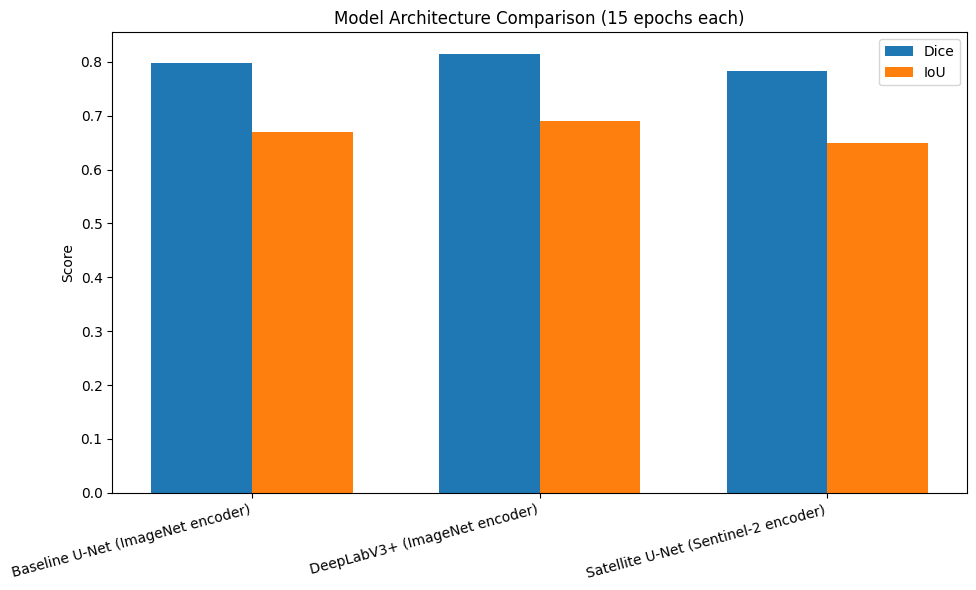

Summary:
  Baseline U-Net (ImageNet encoder)      | Dice: 0.7980 | IoU: 0.6694
  DeepLabV3+ (ImageNet encoder)          | Dice: 0.8139 | IoU: 0.6899
  Satellite U-Net (Sentinel-2 encoder)   | Dice: 0.7827 | IoU: 0.6484

Best architecture by Dice: 'DeepLabV3+ (ImageNet encoder)'
This will now be retrained from scratch for the full FINAL_EPOCHS count below.


In [27]:
# =====================================
# Compare Results
# =====================================

names = list(model_comparison_results.keys())
final_dice = [model_comparison_results[n]["final_dice"] for n in names]
final_iou = [model_comparison_results[n]["final_iou"] for n in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, final_dice, width, label="Dice")
plt.bar(x + width/2, final_iou, width, label="IoU")
plt.xticks(x, names, rotation=15, ha="right")
plt.ylabel("Score")
plt.title(f"Model Architecture Comparison ({COMPARISON_EPOCHS} epochs each)")
plt.legend()
plt.tight_layout()
plt.show()

print("Summary:")
for name in names:
    r = model_comparison_results[name]
    print(f"  {name:38s} | Dice: {r['final_dice']:.4f} | IoU: {r['final_iou']:.4f}")

best_model_name = max(model_comparison_results, key=lambda n: model_comparison_results[n]["final_dice"])
print(f"\nBest architecture by Dice: '{best_model_name}'")
print("This will now be retrained from scratch for the full FINAL_EPOCHS count below.")


## Final Training Run (Week 2 Pretrained Model)

We rebuild the winning architecture with fresh weights (the copies above
were only trained for `COMPARISON_EPOCHS`) and train it for the full
`FINAL_EPOCHS`, using an encoder-freeze warm-up + discriminative learning
rates. To force a specific architecture instead of the automatic winner,
assign `FINAL_MODEL_NAME` manually, e.g.:
`FINAL_MODEL_NAME = "DeepLabV3+ (ImageNet encoder)"`.


In [28]:
# =====================================
# Build Final Model (winner of the architecture comparison)
# =====================================

FINAL_MODEL_NAME = best_model_name

MODEL_BUILDERS = {
    "Baseline U-Net (ImageNet encoder)": lambda: smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=len(SELECTED_CHANNELS),
        classes=1
    ),
    "DeepLabV3+ (ImageNet encoder)": lambda: smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=len(SELECTED_CHANNELS),
        classes=1
    ),
    "Satellite U-Net (Sentinel-2 encoder)": lambda: build_satellite_unet(
        in_channels=len(SELECTED_CHANNELS), num_classes=1
    ),
}

pretrained_model = MODEL_BUILDERS[FINAL_MODEL_NAME]().to(device)
print(f"Final architecture selected: {FINAL_MODEL_NAME}")

# ---- Warm-up strategy for the pretrained encoder ----
# Freeze the pretrained encoder for the first few epochs so the
# randomly-initialized decoder/head can adapt first, without destroying the
# pretrained features with large early gradients. All three architectures
# expose `.encoder` (smp models do natively), so this code doesn't need to
# know which one won.
FREEZE_ENCODER_EPOCHS = 5

def set_encoder_trainable(model, trainable: bool):
    for param in model.encoder.parameters():
        param.requires_grad = trainable

set_encoder_trainable(pretrained_model, False)
print(f"Encoder frozen for the first {FREEZE_ENCODER_EPOCHS} epoch(s)")


Final architecture selected: DeepLabV3+ (ImageNet encoder)
Encoder frozen for the first 5 epoch(s)


In [29]:
# =====================================
# Define Optimizer
# =====================================

ENCODER_LR = 1e-5   # smaller LR to gently fine-tune pretrained weights
DECODER_LR = 1e-4   # larger LR for the randomly-initialized decoder/head

encoder_params = list(pretrained_model.encoder.parameters())
encoder_param_ids = {id(p) for p in encoder_params}
decoder_params = [p for p in pretrained_model.parameters() if id(p) not in encoder_param_ids]

optimizer = torch.optim.Adam([
    {"params": encoder_params, "lr": ENCODER_LR},
    {"params": decoder_params, "lr": DECODER_LR},
])


In [30]:
# =====================================
# Train Model
# =====================================

FINAL_EPOCHS = 100  # more epochs than COMPARISON_EPOCHS used to pick the architecture

train_losses = []
val_losses = []
dice_scores = []
iou_scores = []

for epoch in range(FINAL_EPOCHS):

    if epoch == FREEZE_ENCODER_EPOCHS:
        set_encoder_trainable(pretrained_model, True)
        print(f"--> Encoder unfrozen at epoch {epoch+1}, fine-tuning full network")

    train_loss = train_one_epoch(pretrained_model, train_loader, optimizer, criterion, device)
    val_loss, dice, iou = validate_one_epoch(pretrained_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    dice_scores.append(dice)
    iou_scores.append(iou)

    print(
        f"Epoch [{epoch+1}/{FINAL_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {dice:.4f} | "
        f"IoU: {iou:.4f}"
    )


c:\Python\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch [1/100] | Train Loss: 0.6541 | Val Loss: 0.6745 | Dice: 0.5215 | IoU: 0.3580
Epoch [2/100] | Train Loss: 0.5459 | Val Loss: 0.5577 | Dice: 0.5676 | IoU: 0.4036
Epoch [3/100] | Train Loss: 0.4924 | Val Loss: 0.4673 | Dice: 0.5923 | IoU: 0.4254
Epoch [4/100] | Train Loss: 0.4569 | Val Loss: 0.4555 | Dice: 0.6226 | IoU: 0.4592
Epoch [5/100] | Train Loss: 0.4288 | Val Loss: 0.4134 | Dice: 0.6224 | IoU: 0.4588
--> Encoder unfrozen at epoch 6, fine-tuning full network
Epoch [6/100] | Train Loss: 0.3950 | Val Loss: 0.3860 | Dice: 0.6331 | IoU: 0.4700
Epoch [7/100] | Train Loss: 0.4035 | Val Loss: 0.3217 | Dice: 0.6424 | IoU: 0.4809
Epoch [8/100] | Train Loss: 0.3808 | Val Loss: 0.3355 | Dice: 0.6481 | IoU: 0.4851
Epoch [9/100] | Train Loss: 0.3661 | Val Loss: 0.3216 | Dice: 0.6636 | IoU: 0.5020
Epoch [10/100] | Train Loss: 0.3638 | Val Loss: 0.2806 | Dice: 0.7046 | IoU: 0.5482
Epoch [11/100] | Train Loss: 0.3402 | Val Loss: 0.3038 | Dice: 0.7145 | IoU: 0.5586
Epoch [12/100] | Train Loss

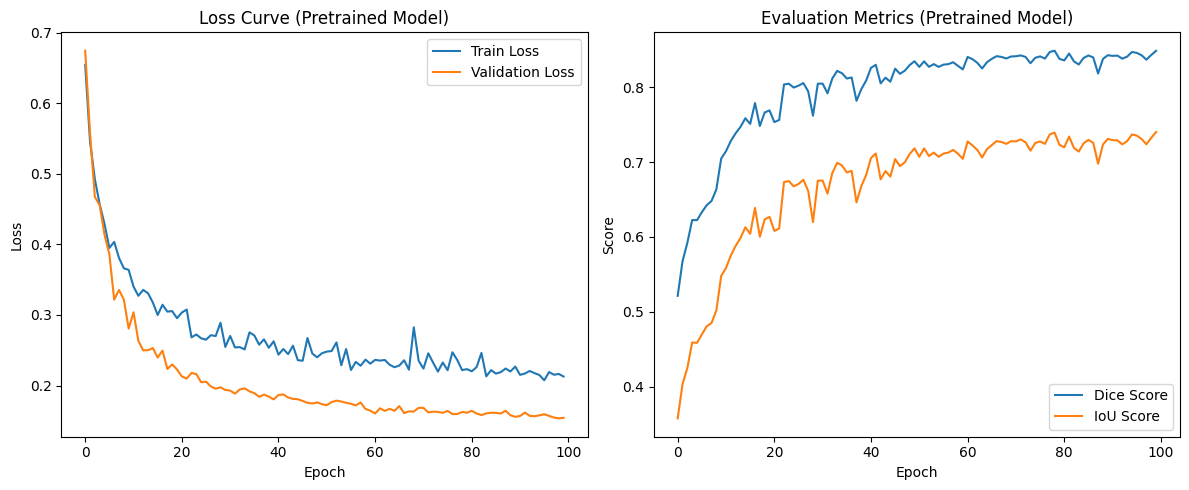

In [31]:
# =====================================
# Plot Training History - Pretrained Model
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve (Pretrained Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dice_scores, label="Dice Score")
plt.plot(iou_scores, label="IoU Score")
plt.title("Evaluation Metrics (Pretrained Model)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
# =====================================
# Full Metrics - Pretrained Model
# =====================================

pretrained_metrics = evaluate_full_metrics(pretrained_model, val_loader, device)

print(f"{FINAL_MODEL_NAME} - Validation Metrics")
for k, v in pretrained_metrics.items():
    print(f"  {k:10s}: {v:.4f}")


DeepLabV3+ (ImageNet encoder) - Validation Metrics
  Dice      : 0.8484
  IoU       : 0.7401
  Precision : 0.8646
  Recall    : 0.8506
  F1        : 0.8576
